## HW5

In [281]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd


#### Loading Data

In [282]:
data = pd.read_csv('HW05_data.csv')
data.head()

X = data.drop('Y',axis=1)
y = data['Y']
y.value_counts()

#print(X.shape)
#print(X.head())
#print(y.shape)

Y
benign       357
malignant    212
Name: count, dtype: int64

#### Preprocessing

In [283]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
#print(encoder.classes_)
#print(y_encoded.shape)
#print(X.shape)
(x_train, x_test, y_train, y_test) = train_test_split(np.asarray(X), y_encoded, test_size=0.25, random_state=42)
pd.DataFrame(y_train).value_counts()
#print(x_train.shape)
#print(x_test.shape)


0
0    268
1    158
Name: count, dtype: int64

#### Training

##### Search for Optimal K Parameter based on error rate

Optimal K value: 11


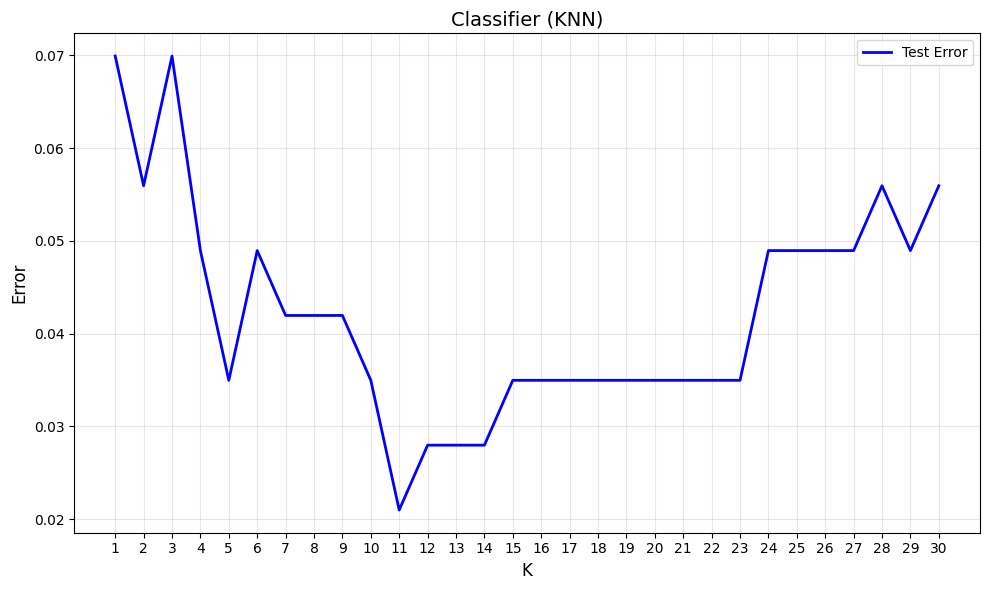

In [284]:
#All Gathered from AML_s26_knn.ipynb and slightly modified for this dataset
all_k =[]
all_err=[]

#Identify Best K to use on KNN Classifier (from K=1 to K=30)
max_K = 30
for K in range(1,max_K+1):
    knn = KNeighborsClassifier(n_neighbors=K)
    y_pred = knn.fit(x_train, y_train).predict(x_test)
    error = np.mean(y_test != y_pred)
    all_k.append(K)
    all_err.append(error)

best_k = all_k[np.argmin(all_err)]
print("Optimal K value:", best_k)


# Plotting the error rates for different K values
plt.figure(1, figsize=(10, 6))

plt.plot(all_k, all_err, linewidth=2, label="Test Error", color='blue')
plt.xlabel("K", fontsize=12)
plt.ylabel("Error", fontsize=12)
plt.title(f"Classifier (KNN)", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(1, max_K+1, 1))
plt.tight_layout()
plt.savefig("knn_error_rates.png", dpi=300)
plt.show()

##### Run a 5-Fold Cross Validation on the knn model choosing the best model from all the folds

In [285]:

#Define Fold with 5 splits, shuffling, and a fixed random state. 
#Chose 5 since this is most common with a data set of this size, and provides a good balance.
fold = KFold(n_splits=5, shuffle=True, random_state=42)

models = []
scores = []

#Run K-Fold CV on KNN Classifier with best_k neighbors
for train_idx, val_idx in fold.split(x_train):
    X_tr, X_val = x_train[train_idx], x_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    model = KNeighborsClassifier(n_neighbors=best_k)
    model.fit(X_tr, y_tr)
    score = model.score(X_val, y_val)
    models.append(model)
    scores.append(score)

cv = np.array(scores)
best_model = models[np.argmax(cv)]
print(f"\nCV Results ({len(cv)} folds):")
print("-" * 25)
print(f"   {'Fold':<10} {'Accuracy':<12}")
print("-" * 25)

for i in range(len(cv)):
    print(f"   Fold {i+1:<5} {cv[i]:<12.4f}")

print("-" * 25)
print(f"   {'Mean':<10} {cv.mean():<12.4f}")
print(f"   {'Std':<10} {cv.std():<12.4f}")



CV Results (5 folds):
-------------------------
   Fold       Accuracy    
-------------------------
   Fold 1     0.8953      
   Fold 2     0.8824      
   Fold 3     0.9765      
   Fold 4     0.9412      
   Fold 5     0.9059      
-------------------------
   Mean       0.9202      
   Std        0.0342      


#### Evaluation

benign


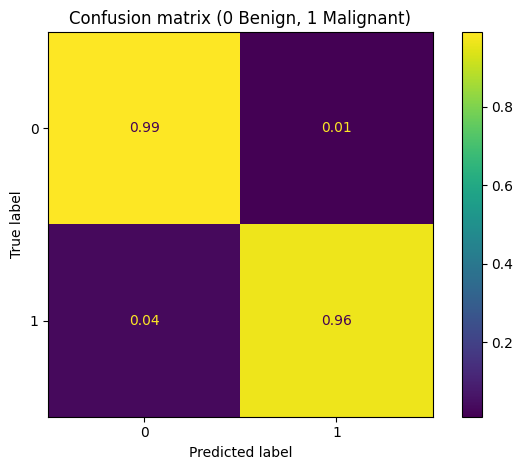

In [ ]:
cm = confusion_matrix(y_test, best_model.predict(x_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_).from_predictions(y_test,normalize="true", values_format=".2f", y_pred=best_model.predict(x_test))
plt.title("Confusion matrix (0 Benign, 1 Malignant)")
plt.tight_layout()
plt.savefig("knn_confusion_matrix.png", dpi=300)
plt.show()